# House Price Prediction Using Machine Learning

**Course:** DAT 604 Machine Learning

**Assessment:** Continuous Assessment 2

## Business Problem Framing

A real estate company needs a reliable way to estimate property values. Right now, agents compare recent sales manually, which is slow and subjective. A regression model trained on historical data can provide an objective starting estimate.

## Data Collection & Preparation

This section loads the data, splits it before any cleaning to prevent data leakage, and imputes missing values using only training-set statistics.

In [1]:
import os

# Download and install the necessary packages
!pip install pandas numpy matplotlib seaborn scipy scikit-learn kaggle -q

# Download the credit risk dataset
!kaggle datasets download -d rileydrizzy/house-prices-advanced-regression-techniques-data --unzip -p .
import os
print("\nDataset downloaded successfully.")
print("Files:", os.listdir('.'))


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Dataset URL: https://www.kaggle.com/datasets/rileydrizzy/house-prices-advanced-regression-techniques-data
License(s): MIT
100%|███████████████████████████████████████| 94.0k/94.0k [00:00<00:00, 970kB/s]


Dataset downloaded successfully.
Files: ['House_Prices_Prediction.ipynb', '.gitignore', 'README.md', 'house_prices.csv', '.git']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats

# Set seed for reproducibility
np.random.seed(42)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('house_prices.csv')

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Data types:")
print(df.dtypes)

Data types:
Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object


The dataset is split into Train (70%), Validation (15%), and Test (15%) **before** any imputation or scaling. All cleaning statistics come from the training set only.

In [4]:
df = df.drop_duplicates()
df = df.drop('Id', axis=1)

X_raw = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_temp, X_test, y_temp, y_test = train_test_split(X_raw, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

# Reset indices so everything lines up
X_train = X_train.reset_index(drop=True); y_train = y_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True);   y_val   = y_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True);  y_test  = y_test.reset_index(drop=True)

print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_test.shape[0]} samples")

Train:      1021 samples
Validation: 220 samples
Test:       219 samples


Data Cleaning

In [5]:
# MSSubClass looks numeric but is actually a building-type code
X_train['MSSubClass'] = X_train['MSSubClass'].astype(str)
X_val['MSSubClass']   = X_val['MSSubClass'].astype(str)
X_test['MSSubClass']  = X_test['MSSubClass'].astype(str)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Impute using training-set medians only
train_medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_val[num_cols]   = X_val[num_cols].fillna(train_medians)
X_test[num_cols]  = X_test[num_cols].fillna(train_medians)

X_train[cat_cols] = X_train[cat_cols].fillna('None')
X_val[cat_cols]   = X_val[cat_cols].fillna('None')
X_test[cat_cols]  = X_test[cat_cols].fillna('None')

print("Missing values after cleaning:", X_train.isnull().sum().sum())
print(f"Numerical features: {len(num_cols)}, Categorical features: {len(cat_cols)}")

Missing values after cleaning: 0
Numerical features: 35, Categorical features: 44


## Exploratory Data Analysis (EDA)

All EDA is done on the training set only. The goal is to understand what drives house prices and identify any data issues that should guide how features are prepared for modelling.

### Distribution of House Prices

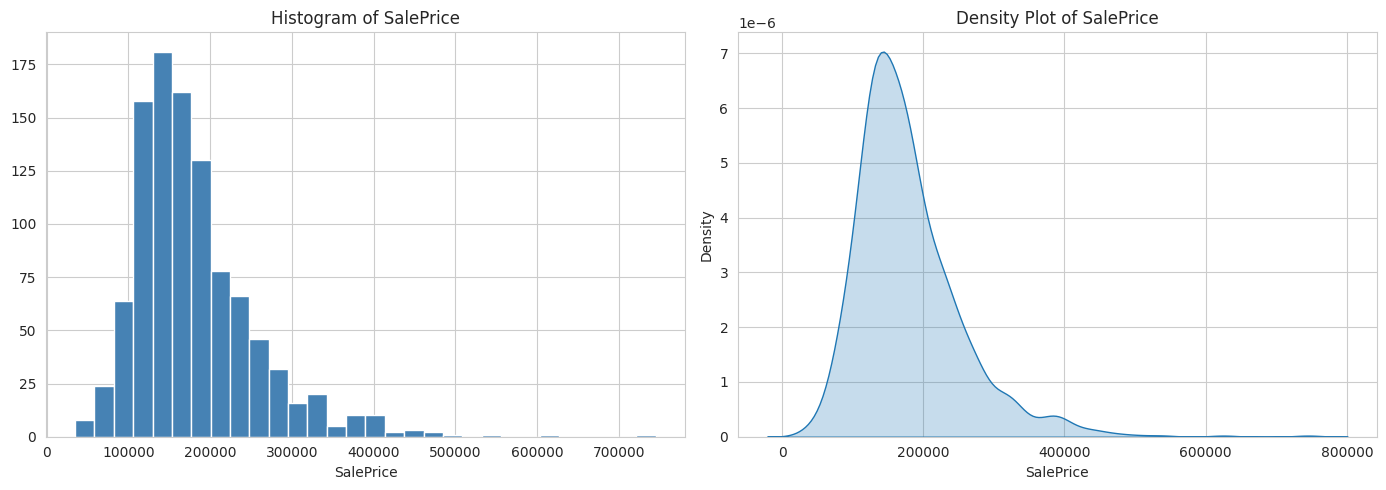

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram of SalePrice')
axes[0].set_xlabel('SalePrice')

sns.kdeplot(y_train, fill=True, ax=axes[1])
axes[1].set_title('Density Plot of SalePrice')
axes[1].set_xlabel('SalePrice')

plt.tight_layout()
plt.show()

Prices are clearly right-skewed. The bulk of houses sell between roughly $100k and $250k, but there is a long tail stretching past $400k where a handful of expensive properties sit.

### Univariate Analysis

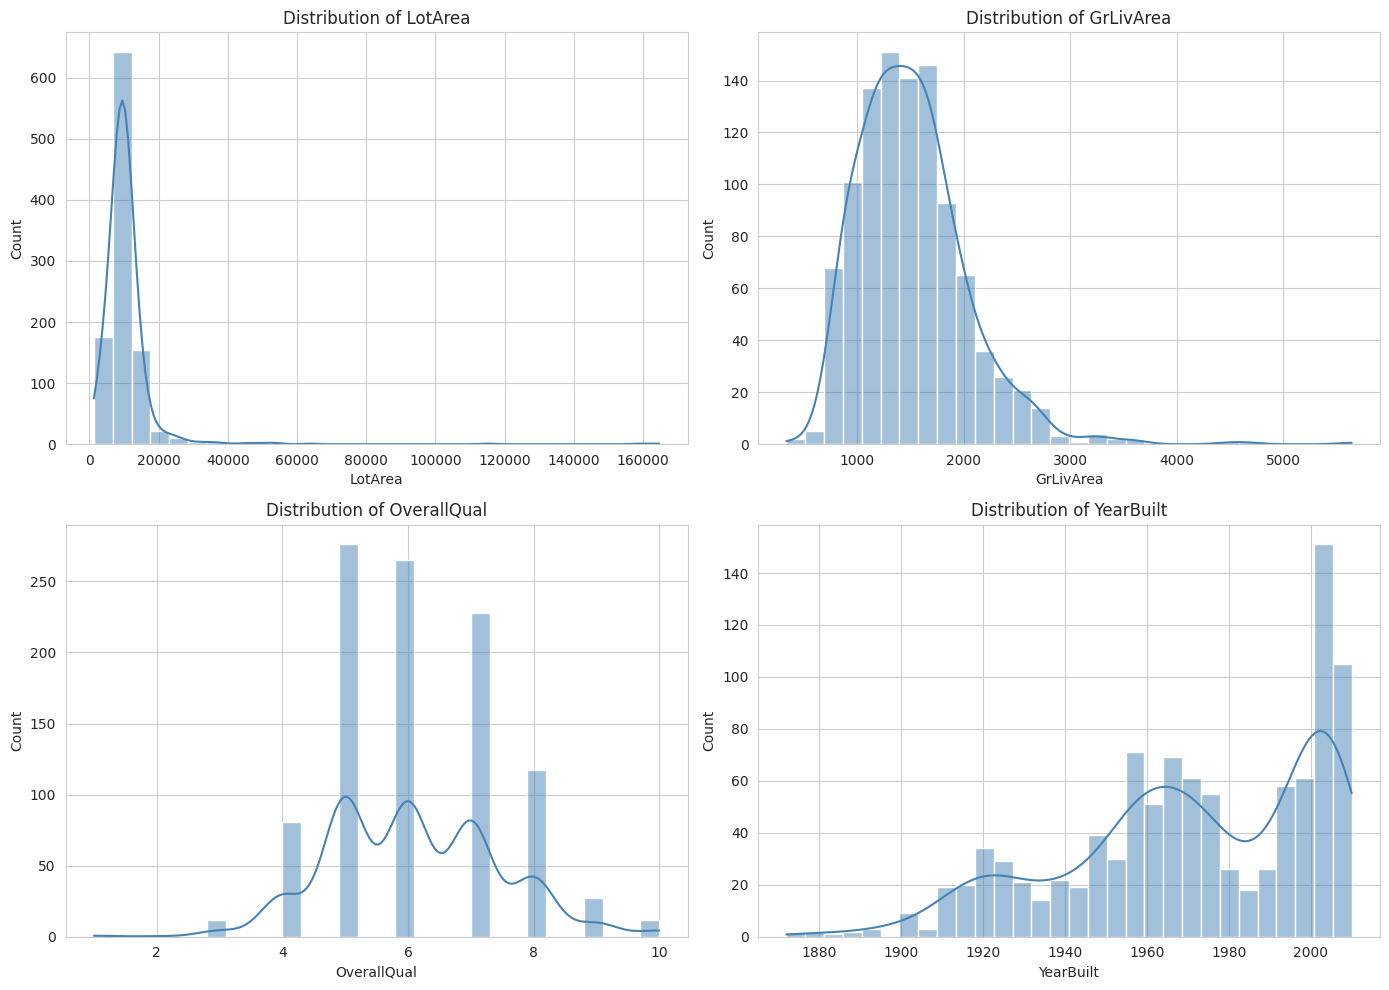

In [7]:
features_uni = ['LotArea', 'GrLivArea', 'OverallQual', 'YearBuilt']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_uni):
    sns.histplot(X_train[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

LotArea and GrLivArea are both right-skewed with a few very large properties pulling the tail. OverallQual peaks around 5-6 (average quality), and YearBuilt is concentrated in recent decades, meaning this dataset has more newer homes than old ones.

### Bivariate Analysis

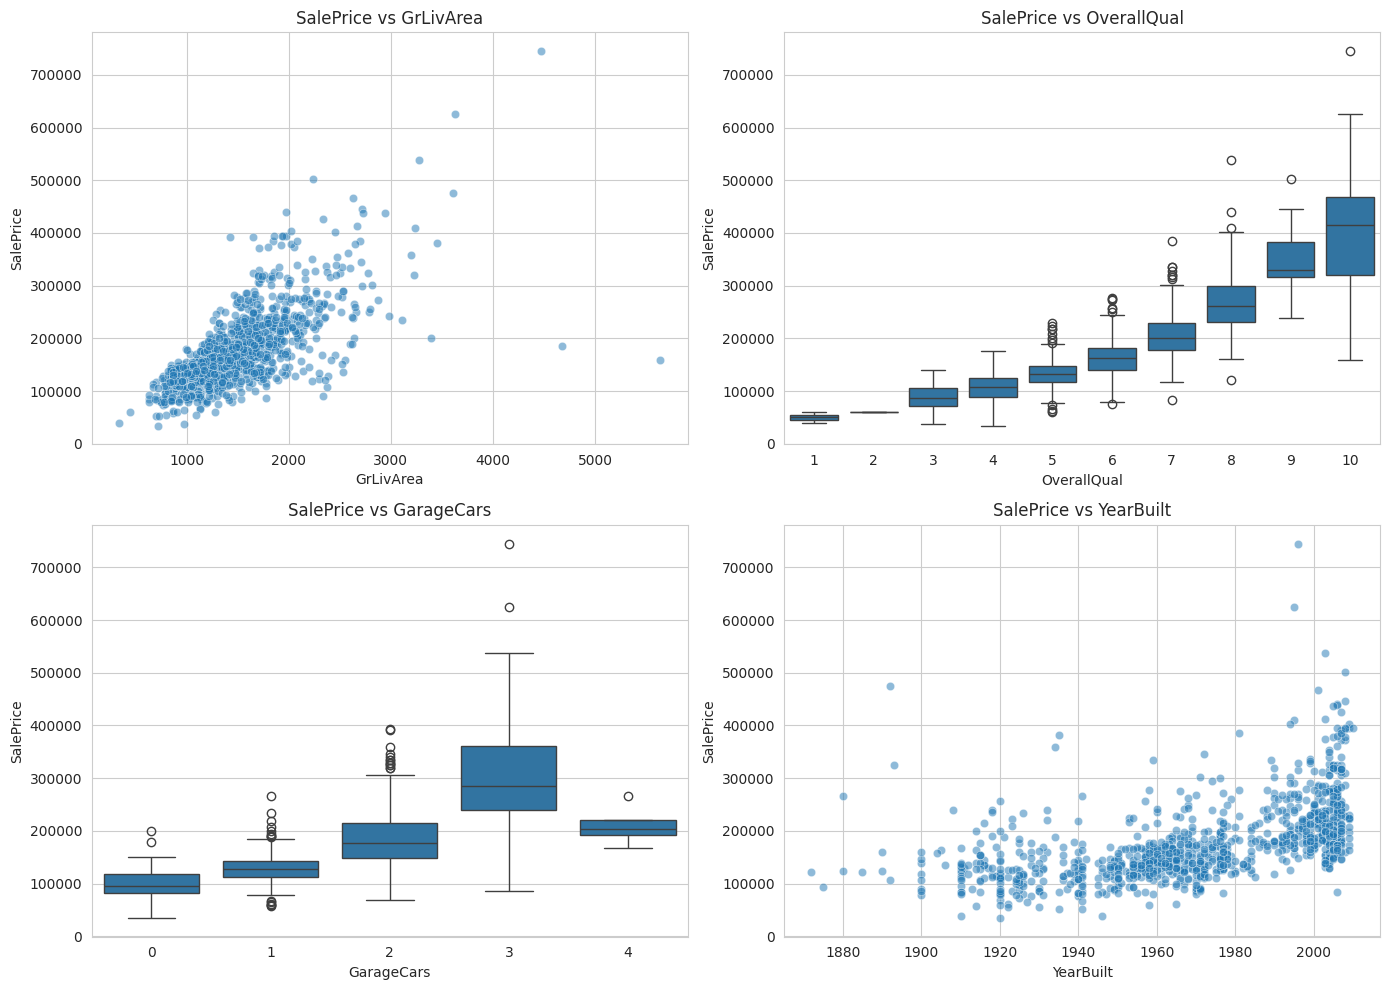

In [8]:
df_train_eda = X_train.copy()
df_train_eda['SalePrice'] = y_train

features_biv = ['GrLivArea', 'OverallQual', 'GarageCars', 'YearBuilt']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_biv):
    if df_train_eda[col].nunique() < 15:
        sns.boxplot(x=df_train_eda[col], y=df_train_eda['SalePrice'], ax=axes[i])
    else:
        sns.scatterplot(x=df_train_eda[col], y=df_train_eda['SalePrice'], alpha=0.5, ax=axes[i])
    axes[i].set_title(f'SalePrice vs {col}')

plt.tight_layout()
plt.show()

The scatter plot of GrLivArea vs SalePrice shows a strong upward trend with a few outliers at large areas. The OverallQual boxplot reveals a clear staircase pattern where each quality step up adds a noticeable jump in median price. GarageCars shows diminishing returns after 2 cars. YearBuilt has a general upward trend but with a lot of scatter, since old houses vary widely in condition.

### Correlation Heatmap

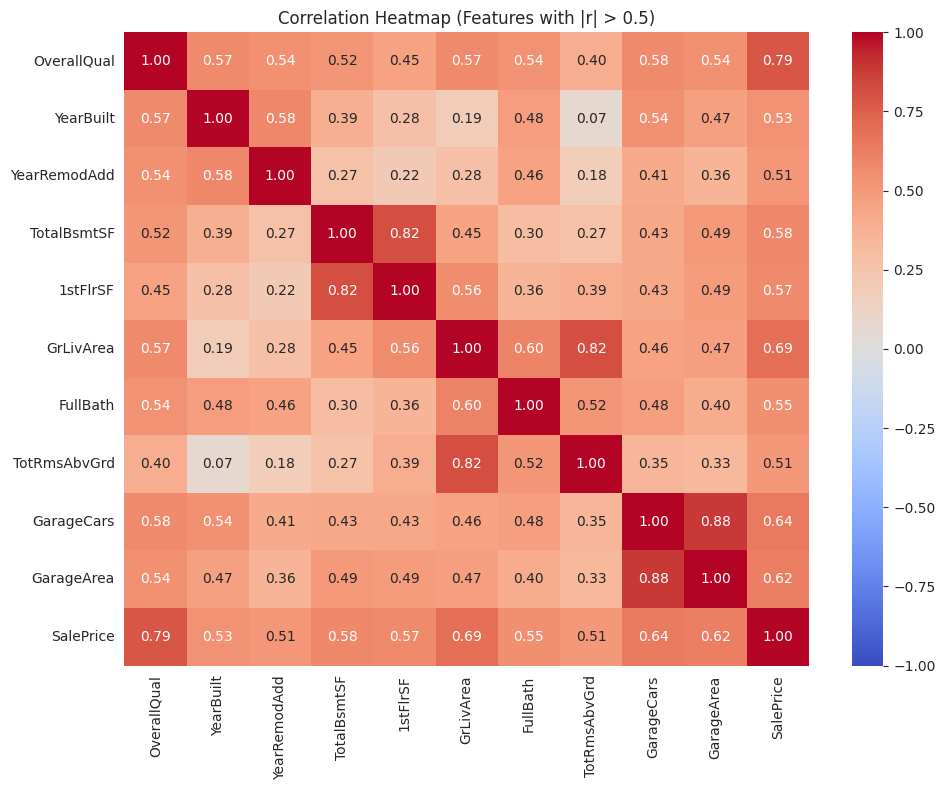

In [9]:
plt.figure(figsize=(10, 8))
numeric_train = df_train_eda.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_train.corr()

top_corr = corr_matrix.index[abs(corr_matrix['SalePrice']) > 0.5]
sns.heatmap(numeric_train[top_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Features with |r| > 0.5)')
plt.tight_layout()
plt.show()

OverallQual (r ~ 0.79) and GrLivArea (r ~ 0.71) have the strongest correlations with SalePrice. GarageCars, GarageArea, TotalBsmtSF, and 1stFlrSF are also notable. Importantly, several features are also highly correlated with each other (GarageArea/GarageCars at 0.88, TotalBsmtSF/1stFlrSF at 0.82, GrLivArea/TotRmsAbvGrd at 0.82), which is a red flag for multicollinearity.

### Checking for Exact Linear Combinations

The high correlations above hint at possible structural relationships. Let us verify:

In [10]:
bsmt_check = (X_train['BsmtFinSF1'] + X_train['BsmtFinSF2'] + X_train['BsmtUnfSF'] - X_train['TotalBsmtSF']).abs().max()
floor_check = (X_train['1stFlrSF'] + X_train['2ndFlrSF'] + X_train['LowQualFinSF'] - X_train['GrLivArea']).abs().max()

print(f"BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF == TotalBsmtSF?  Max diff: {bsmt_check}")
print(f"1stFlrSF + 2ndFlrSF + LowQualFinSF == GrLivArea?     Max diff: {floor_check}")

print("\nBoth are exact sums. Including all of them would make the OLS matrix singular.")

BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF == TotalBsmtSF?  Max diff: 0
1stFlrSF + 2ndFlrSF + LowQualFinSF == GrLivArea?     Max diff: 0

Both are exact sums. Including all of them would make the OLS matrix singular.


### Key Insights
1. Prices are right-skewed with a few expensive outliers.
2. OverallQual has the single strongest correlation with price.
3. Living area (GrLivArea) shows a strong positive linear relationship.
4. Newer houses generally sell for more, but old houses vary widely.
5. Several features form **exact linear combinations** (basement sub-areas sum to TotalBsmtSF, floor areas sum to GrLivArea). These must be handled before fitting the model, or the matrix will be singular.
6. Additional highly correlated pairs (GarageArea/GarageCars, GarageYrBlt/YearBuilt) can also destabilise unregularised regression.

### Feature Preparation

Based on the EDA findings above, two pipelines are built:

1. **Numerical-only (for Linear Regression):** The exact linear combinations and highly correlated pairs discovered in the EDA are removed. The component features (BsmtFinSF1/SF2/UnfSF, 1stFlrSF/2ndFlrSF/LowQualFinSF) are dropped in favour of their totals (TotalBsmtSF, GrLivArea). GarageArea, GarageYrBlt, and TotRmsAbvGrd are also dropped. This leaves about 26 stable features.
2. **Full encoded (for Ridge/Lasso):** All 79 features are one-hot encoded (~263 columns). Regularisation handles both collinearity and dimensionality.

In [11]:
# Pipeline for Ridge/Lasso
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols)
    ])

X_train_full = preprocessor_full.fit_transform(X_train)
X_val_full   = preprocessor_full.transform(X_val)
X_test_full  = preprocessor_full.transform(X_test)

full_feature_names = [f.split('__', 1)[-1] for f in preprocessor_full.get_feature_names_out()]

print(f"Full encoded shape (for Ridge/Lasso): {X_train_full.shape}")

# Numerical-only pipeline for Linear Regression
# drop features that form exact linear combinations or high correlation
drop_for_lr = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF',
               'LowQualFinSF', 'GarageArea', 'GarageYrBlt', 'TotRmsAbvGrd']
lr_num_cols = [c for c in num_cols if c not in drop_for_lr]

scaler_num = StandardScaler()
X_train_num = pd.DataFrame(scaler_num.fit_transform(X_train[lr_num_cols]), columns=lr_num_cols)
X_val_num   = pd.DataFrame(scaler_num.transform(X_val[lr_num_cols]),       columns=lr_num_cols)
X_test_num  = pd.DataFrame(scaler_num.transform(X_test[lr_num_cols]),      columns=lr_num_cols)

print(f"Numerical-only shape (for Linear Regression): {X_train_num.shape}")

Full encoded shape (for Ridge/Lasso): (1021, 263)
Numerical-only shape (for Linear Regression): (1021, 26)


## Model Training: Linear Regression

A baseline Linear Regression is trained on the reduced set of 26 numerical features. The exact linear combinations and highly correlated pairs identified during EDA have been removed so the OLS solution is numerically stable.

In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train_num, y_train)

print(f"Intercept: {lr_model.intercept_:,.2f}\n")

lr_coefficients = pd.DataFrame({
    'Feature': lr_num_cols,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Coefficients (sorted by value):")
lr_coefficients

Intercept: 179,264.84

Coefficients (sorted by value):


,Feature,Coefficient
8,GrLivArea,25139.270461
2,OverallQual,24268.549287
16,GarageCars,10372.824345
4,YearBuilt,7522.018948
9,BsmtFullBath,6860.512047
6,MasVnrArea,5416.314420
17,WoodDeckSF,4355.594674
5,YearRemodAdd,4304.029626
7,TotalBsmtSF,3495.945946
1,LotArea,3386.581511


After scaling, the coefficient size directly reflects how strongly each feature affects the prediction (in dollar terms per one standard deviation increase):

* **OverallQual:** Largest positive coefficient. Each standard-deviation increase in quality rating adds the most to the predicted price.
* **GrLivArea:** Second largest. More living space reliably pushes prices up.
* **YearBuilt:** Positive coefficient confirms newer construction adds value.

These align with the EDA findings

## Evaluation of Linear Regression

These plots evaluate how well the Linear Regression baseline captures the underlying patterns.

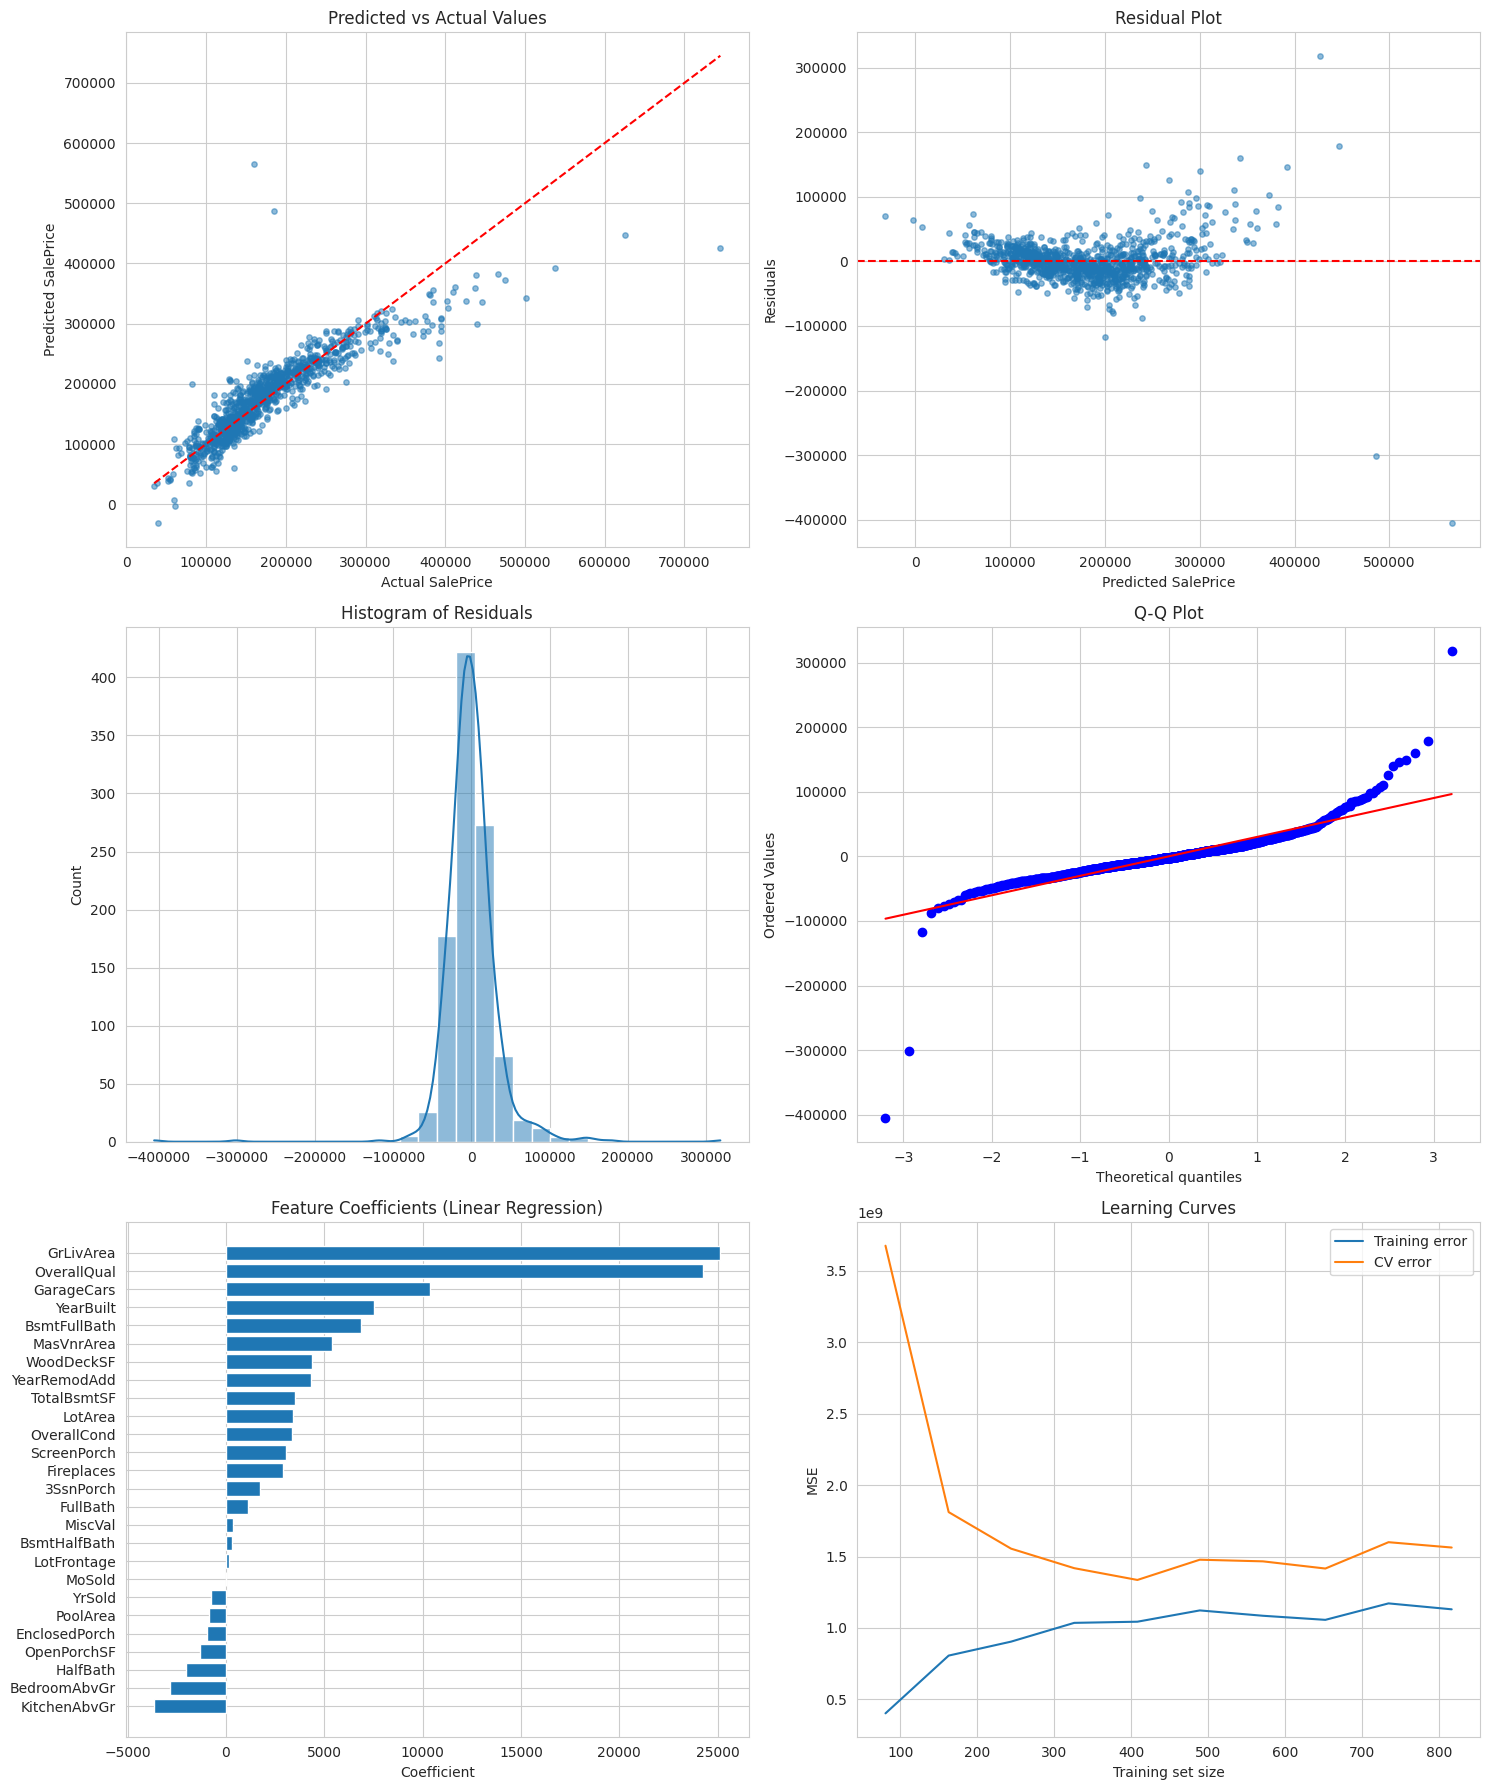

In [13]:
y_pred_train_lr = lr_model.predict(X_train_num)
residuals_lr = y_train.values - y_pred_train_lr

fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Predicted vs Actual
axes[0, 0].scatter(y_train, y_pred_train_lr, alpha=0.5, s=15)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0, 0].set_xlabel('Actual SalePrice')
axes[0, 0].set_ylabel('Predicted SalePrice')
axes[0, 0].set_title('Predicted vs Actual Values')

# Residual Plot
axes[0, 1].scatter(y_pred_train_lr, residuals_lr, alpha=0.5, s=15)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted SalePrice')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')

# Histogram of Residuals
sns.histplot(residuals_lr, bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histogram of Residuals')

# Q-Q Plot
stats.probplot(residuals_lr, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

# Feature Coefficient Bar Chart
lr_coef_sorted = lr_coefficients.sort_values('Coefficient', ascending=True)
axes[2, 0].barh(lr_coef_sorted['Feature'], lr_coef_sorted['Coefficient'])
axes[2, 0].set_title('Feature Coefficients (Linear Regression)')
axes[2, 0].set_xlabel('Coefficient')

# Learning Curves
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(), X_train_num, y_train, cv=5,
    scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10))

axes[2, 1].plot(train_sizes, -train_scores.mean(axis=1), label='Training error')
axes[2, 1].plot(train_sizes, -val_scores.mean(axis=1), label='CV error')
axes[2, 1].set_xlabel('Training set size')
axes[2, 1].set_ylabel('MSE')
axes[2, 1].set_title('Learning Curves')
axes[2, 1].legend()

plt.tight_layout()
plt.show()

- **Predicted vs Actual:** Points cluster around the diagonal line, showing reasonable accuracy for the numerical-only baseline. There is more scatter at high prices, meaning the model has a harder time with luxury homes.
- **Residual Plot:** Residuals fan out slightly at higher predicted values (heteroscedasticity). This is typical in housing data since expensive properties have more variable pricing.
- **Histogram of Residuals:** Roughly bell-shaped and centred on zero, with slightly heavier tails from luxury outliers.
- **Q-Q Plot:** The middle section follows the diagonal well, but the tails deviate, confirming the heavy-tailed residual pattern.
- **Feature Coefficients:** OverallQual and GrLivArea dominate the positive side, consistent with the EDA.
- **Learning Curves:** Training error rises gradually and stabilises as the model has to fit more varied data. CV error starts high and drops sharply, then flattens out. The two curves approach each other but a gap remains, which is typical when the dataset is modest in size relative to the complexity of the problem.

## Hyperparameter Tuning

Ridge and Lasso are trained on the full one-hot-encoded feature set (263 columns). These regularised models add a penalty term to the loss function that shrinks large coefficients, which prevents the numerical instability that plain OLS suffers from in high-dimensional or collinear settings.

In [14]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge_grid = GridSearchCV(
    Ridge(max_iter=10000), {'alpha': alphas},
    cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_full, y_train)

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000), {'alpha': alphas},
    cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_full, y_train)

print(f"Best Ridge Alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best Ridge CV MSE: {-ridge_grid.best_score_:,.2f}")

print(f"\nBest Lasso Alpha: {lasso_grid.best_params_['alpha']}")
print(f"Best Lasso CV MSE: {-lasso_grid.best_score_:,.2f}")

best_model_name = "Ridge" if ridge_grid.best_score_ > lasso_grid.best_score_ else "Lasso"
print(f"\nBest Overall Model: {best_model_name}")

Best Ridge Alpha: 10
Best Ridge CV MSE: 1,281,963,544.95

Best Lasso Alpha: 100
Best Lasso CV MSE: 1,335,903,853.19

Best Overall Model: Ridge


### Ridge and Lasso Learning Curves

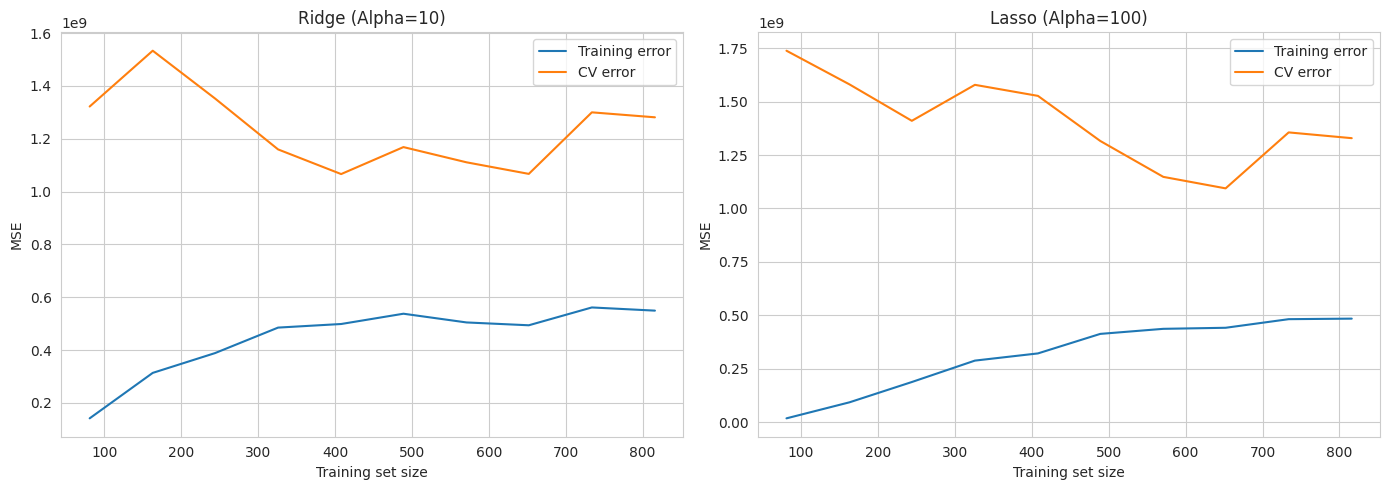

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_sizes, train_sc, val_sc = learning_curve(
    ridge_grid.best_estimator_, X_train_full, y_train, cv=5,
    scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10))

axes[0].plot(train_sizes, -train_sc.mean(axis=1), label='Training error')
axes[0].plot(train_sizes, -val_sc.mean(axis=1), label='CV error')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('MSE')
axes[0].set_title(f"Ridge (Alpha={ridge_grid.best_params_['alpha']})")
axes[0].legend()

train_sizes, train_sc, val_sc = learning_curve(
    lasso_grid.best_estimator_, X_train_full, y_train, cv=5,
    scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10))

axes[1].plot(train_sizes, -train_sc.mean(axis=1), label='Training error')
axes[1].plot(train_sizes, -val_sc.mean(axis=1), label='CV error')
axes[1].set_xlabel('Training set size')
axes[1].set_ylabel('MSE')
axes[1].set_title(f"Lasso (Alpha={lasso_grid.best_params_['alpha']})")
axes[1].legend()

plt.tight_layout()
plt.show()

The Ridge and Lasso learning curves show no explosive spikes, as the regularisation penalty keeps coefficients bounded. However, the validation error fluctuates rather than converging smoothly to the training error. This reflects the high feature-to-sample ratio (263 encoded features vs roughly 800 training samples per CV fold), and suggests the models would benefit from more training data.

## Evaluation of Model Performance

All three models are evaluated on the held-out test set that was never seen during training or tuning.

In [16]:
models = {
    'Linear Regression (num only)': (lr_model, X_test_num),
    'Ridge (all features)':         (ridge_grid.best_estimator_, X_test_full),
    'Lasso (all features)':         (lasso_grid.best_estimator_, X_test_full)
}

results = []
for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    results.append({
        'Model': name,
        'MAE':   mean_absolute_error(y_test, y_pred),
        'MSE':   mean_squared_error(y_test, y_pred),
        'RMSE':  np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2':    r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression (num only),23598.449497,1.612686e+09,40158.255854,0.801358
Ridge (all features),19727.582061,1.136626e+09,33713.877450,0.859997
Lasso (all features),19172.056367,1.092323e+09,33050.309214,0.865454


* **MAE:** The average dollar amount the prediction is off by an MAE of ~$20,000 means on a typical house the estimate is within $20k of the real price.
* **MSE:** Squares the errors, so big misses on expensive houses are penalised much more than small ones on cheap houses.
* **RMSE:** The square root of MSE, back in dollar terms. An RMSE around $33,000-$40,000 represents the typical magnitude of error.
* **R-squared:** The fraction of price variation explained by the model. The baseline LR achieves about 0.80 using only numerical features. Ridge and Lasso push this to about 0.86 by safely leveraging all features including categorical ones.

The regularised models clearly outperform the numerical-only baseline because they can use neighbourhood, exterior material, and other categorical information without the overfitting risk that would break plain OLS on 263 columns.

## Business Recommendations

**Key price drivers:**
Overall material quality and above-ground living area are the two strongest predictors by a wide margin. Garage capacity, total basement area, and year of construction also contribute meaningfully.

**Pricing advice for agents:**
Use the model's output as a data-backed starting point. Adjust from there for factors the data does not capture: kerb appeal, local market conditions at the time of listing, and any recent renovations not reflected in the recorded features.

**Upgrades worth investing in:**
* Kitchen and bathroom modernisations directly improve OverallQual, which has the single largest coefficient.
* Finishing a basement adds usable square footage at a lower cost per sqft than a new addition.
* Adding or expanding a garage is associated with a solid price uplift, though with diminishing returns beyond 2 cars.